In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("healthcare_realistic_dataset_515_rows.xlsx")

In [3]:
df.head()

,Patient_ID,Age,Gender,Blood_Group,Height_cm,Weight_kg,BMI,Disease,Department,City,Admission_Date,Discharge_Date,Treatment_Cost,Insurance_Status,Outcome
0,P0001,24.0,Male,A+,162,56.0,21.3,Migraine,Pulmonology,Kolkata,2025-07-28,2025-08-06,92083.0,No,Recovered
1,P0002,38.0,Male,B+,153,88.0,37.6,Diabetes,General Medicine,Hyderabad,2025-10-15,2025-10-26,27967.0,No,Recovered
2,P0003,18.0,Male,B+,165,102.0,37.5,Asthma,Cardiology,Delhi,2025-02-22,2025-02-24,243852.0,No,Critical
3,P0004,79.0,Female,O-,161,105.0,40.5,COVID-19,Pulmonology,Patna,2025-01-19,2025-01-29,143169.0,No,Recovered
4,P0005,68.0,Female,O+,186,110.0,31.8,Arthritis,Pulmonology,Pune,2025-08-11,2025-08-29,227125.0,Yes,Critical


In [4]:
df.tail()

,Patient_ID,Age,Gender,Blood_Group,Height_cm,Weight_kg,BMI,Disease,Department,City,Admission_Date,Discharge_Date,Treatment_Cost,Insurance_Status,Outcome
510,P0010,26.0,Male,O+,177,90.0,28.7,Diabetes,Pulmonology,Bengaluru,2025-12-29,2026-01-01,24263.0,No,Recovered
511,P0195,55.0,Male,O-,146,64.0,30.0,Migraine,General Medicine,Mumbai,2025-05-16,2025-05-22,NaN,Yes,Recovered
512,P0407,NaN,Female,AB+,175,72.0,23.5,Migraine,Cardiology,Hyderabad,2025-07-16,2025-07-24,244973.0,Yes,Ongoing
513,P0085,59.0,Female,O-,190,45.0,12.5,Diabetes,Neurology,Pune,2025-12-01,2025-12-16,73031.0,Yes,Ongoing
514,P0372,31.0,Male,B-,156,96.0,39.4,Heart Disease,General Medicine,Kolkata,2025-04-11,2025-04-23,246894.0,Yes,Recovered


In [5]:
df.sample(5)

,Patient_ID,Age,Gender,Blood_Group,Height_cm,Weight_kg,BMI,Disease,Department,City,Admission_Date,Discharge_Date,Treatment_Cost,Insurance_Status,Outcome
206,P0207,45.0,Female,A+,164,83.0,30.9,Diabetes,Cardiology,Kolkata,2025-06-09,2025-06-20,207010.0,Yes,Critical
472,P0473,56.0,NaN,O+,190,70.0,19.4,Arthritis,Neurology,Patna,2025-11-30,2025-12-13,45174.0,Yes,Recovered
473,P0474,22.0,NaN,O+,174,86.0,28.4,NaN,Neurology,Bengaluru,2025-09-03,2025-09-15,NaN,Yes,Ongoing
176,P0177,72.0,Female,AB-,154,100.0,42.2,COVID-19,General Medicine,Mumbai,2025-05-28,2025-06-09,125659.0,No,Ongoing
249,P0250,27.0,Female,AB-,157,107.0,43.4,Arthritis,General Medicine,Kolkata,2025-01-07,2025-01-09,214953.0,No,Recovered


In [6]:
df.shape

(515, 15)

In [7]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Blood_Group', 'Height_cm', 'Weight_kg',
       'BMI', 'Disease', 'Department', 'City', 'Admission_Date',
       'Discharge_Date', 'Treatment_Cost', 'Insurance_Status', 'Outcome'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        515 non-null    object 
 1   Age               489 non-null    float64
 2   Gender            489 non-null    object 
 3   Blood_Group       489 non-null    object 
 4   Height_cm         515 non-null    int64  
 5   Weight_kg         490 non-null    float64
 6   BMI               515 non-null    float64
 7   Disease           489 non-null    object 
 8   Department        515 non-null    object 
 9   City              515 non-null    object 
 10  Admission_Date    515 non-null    object 
 11  Discharge_Date    515 non-null    object 
 12  Treatment_Cost    488 non-null    float64
 13  Insurance_Status  515 non-null    object 
 14  Outcome           515 non-null    object 
dtypes: float64(4), int64(1), object(10)
memory usage: 60.5+ KB


In [9]:
df.dtypes

Patient_ID           object
Age                 float64
Gender               object
Blood_Group          object
Height_cm             int64
Weight_kg           float64
BMI                 float64
Disease              object
Department           object
City                 object
Admission_Date       object
Discharge_Date       object
Treatment_Cost      float64
Insurance_Status     object
Outcome              object
dtype: object

In [10]:
df.isnull().sum()

Patient_ID           0
Age                 26
Gender              26
Blood_Group         26
Height_cm            0
Weight_kg           25
BMI                  0
Disease             26
Department           0
City                 0
Admission_Date       0
Discharge_Date       0
Treatment_Cost      27
Insurance_Status     0
Outcome              0
dtype: int64

In [11]:
(df.isnull().sum()/len(df))*100

Patient_ID          0.000000
Age                 5.048544
Gender              5.048544
Blood_Group         5.048544
Height_cm           0.000000
Weight_kg           4.854369
BMI                 0.000000
Disease             5.048544
Department          0.000000
City                0.000000
Admission_Date      0.000000
Discharge_Date      0.000000
Treatment_Cost      5.242718
Insurance_Status    0.000000
Outcome             0.000000
dtype: float64

In [12]:
df['Treatment_Cost'].fillna(df['Treatment_Cost'].median(), inplace=True)

C:\Users\RUSHIKESH\AppData\Local\Temp\ipykernel_25516\1194629647.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Treatment_Cost'].fillna(df['Treatment_Cost'].median(), inplace=True)


In [13]:
df['Disease'].fillna(df['Disease'].mode()[0], inplace=True)

C:\Users\RUSHIKESH\AppData\Local\Temp\ipykernel_25516\1489691264.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Disease'].fillna(df['Disease'].mode()[0], inplace=True)


In [14]:
df.duplicated().sum()

np.int64(15)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.columns = df.columns.str.strip()

In [17]:
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    df[col] = df[col].str.strip()

In [18]:
for col in object_cols:
    df[col] = df[col].str.title()

In [19]:
for col in object_cols:
    print(col)
    print(df[col].unique())

Patient_ID
['P0001' 'P0002' 'P0003' 'P0004' 'P0005' 'P0006' 'P0007' 'P0008' 'P0009'
 'P0010' 'P0011' 'P0012' 'P0013' 'P0014' 'P0015' 'P0016' 'P0017' 'P0018'
 'P0019' 'P0020' 'P0021' 'P0022' 'P0023' 'P0024' 'P0025' 'P0026' 'P0027'
 'P0028' 'P0029' 'P0030' 'P0031' 'P0032' 'P0033' 'P0034' 'P0035' 'P0036'
 'P0037' 'P0038' 'P0039' 'P0040' 'P0041' 'P0042' 'P0043' 'P0044' 'P0045'
 'P0046' 'P0047' 'P0048' 'P0049' 'P0050' 'P0051' 'P0052' 'P0053' 'P0054'
 'P0055' 'P0056' 'P0057' 'P0058' 'P0059' 'P0060' 'P0061' 'P0062' 'P0063'
 'P0064' 'P0065' 'P0066' 'P0067' 'P0068' 'P0069' 'P0070' 'P0071' 'P0072'
 'P0073' 'P0074' 'P0075' 'P0076' 'P0077' 'P0078' 'P0079' 'P0080' 'P0081'
 'P0082' 'P0083' 'P0084' 'P0085' 'P0086' 'P0087' 'P0088' 'P0089' 'P0090'
 'P0091' 'P0092' 'P0093' 'P0094' 'P0095' 'P0096' 'P0097' 'P0098' 'P0099'
 'P0100' 'P0101' 'P0102' 'P0103' 'P0104' 'P0105' 'P0106' 'P0107' 'P0108'
 'P0109' 'P0110' 'P0111' 'P0112' 'P0113' 'P0114' 'P0115' 'P0116' 'P0117'
 'P0118' 'P0119' 'P0120' 'P0121' 'P0122'

In [20]:
df['Admission_Date']=pd.to_datetime(df['Admission_Date'])

df['Discharge_Date']=pd.to_datetime(df['Discharge_Date'])

In [21]:
df[df['Age']<0]

,Patient_ID,Age,Gender,Blood_Group,Height_cm,Weight_kg,BMI,Disease,Department,City,Admission_Date,Discharge_Date,Treatment_Cost,Insurance_Status,Outcome


In [22]:
df[df['Treatment_Cost']<0]

,Patient_ID,Age,Gender,Blood_Group,Height_cm,Weight_kg,BMI,Disease,Department,City,Admission_Date,Discharge_Date,Treatment_Cost,Insurance_Status,Outcome


In [26]:
df['Hospital_Stay']=(df['Discharge_Date']-df['Admission_Date']).dt.days

In [27]:
bins=[18,30,45,60,100]

labels=['18-30','31-45','46-60','60+']

df['Age_Group']=pd.cut(df['Age'],bins=bins,labels=labels,include_lowest=True)

In [29]:
df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Patient_ID        500 non-null    object        
 1   Age               475 non-null    float64       
 2   Gender            475 non-null    object        
 3   Blood_Group       475 non-null    object        
 4   Height_cm         500 non-null    int64         
 5   Weight_kg         475 non-null    float64       
 6   BMI               500 non-null    float64       
 7   Disease           500 non-null    object        
 8   Department        500 non-null    object        
 9   City              500 non-null    object        
 10  Admission_Date    500 non-null    datetime64[ns]
 11  Discharge_Date    500 non-null    datetime64[ns]
 12  Treatment_Cost    500 non-null    float64       
 13  Insurance_Status  500 non-null    object        
 14  Outcome           500 non-null 

In [30]:
df.isnull().sum()


Patient_ID           0
Age                 25
Gender              25
Blood_Group         25
Height_cm            0
Weight_kg           25
BMI                  0
Disease              0
Department           0
City                 0
Admission_Date       0
Discharge_Date       0
Treatment_Cost       0
Insurance_Status     0
Outcome              0
Hospital_Stay        0
Age_Group           28
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.to_csv("cleaned_healthcare_dataset.csv",index=False)

In [33]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Admission_Date,Discharge_Date,Treatment_Cost,Hospital_Stay
count,475.000000,500.000000,475.000000,500.000000,500,500,500.000000,500.000000
mean,50.513684,166.890000,78.633684,28.819600,2025-07-01 21:59:02.400000,2025-07-12 15:59:02.400000256,122455.827000,10.750000
min,2.000000,145.000000,25.000000,11.100000,2025-01-02 00:00:00,2025-01-07 00:00:00,5093.000000,1.000000
25%,33.000000,155.000000,60.500000,21.700000,2025-03-26 00:00:00,2025-04-06 00:00:00,62107.500000,6.000000
50%,52.000000,166.000000,79.000000,27.800000,2025-07-08 00:00:00,2025-07-17 00:00:00,124703.500000,11.000000
75%,65.000000,179.000000,95.500000,35.500000,2025-10-10 00:00:00,2025-10-21 00:00:00,181052.500000,16.000000
max,115.000000,190.000000,220.000000,104.600000,2026-01-01 00:00:00,2026-01-17 00:00:00,249921.000000,20.000000
std,19.837348,13.524486,21.461390,9.446619,NaN,NaN,70203.300296,5.846012


In [34]:
df.describe(include='object')

,Patient_ID,Gender,Blood_Group,Disease,Department,City,Insurance_Status,Outcome
count,500,475,475,500,500,500,500,500
unique,500,2,8,8,6,7,2,3
top,P0001,Female,Ab+,Asthma,Neurology,Mumbai,No,Critical
freq,1,244,73,94,102,83,251,171


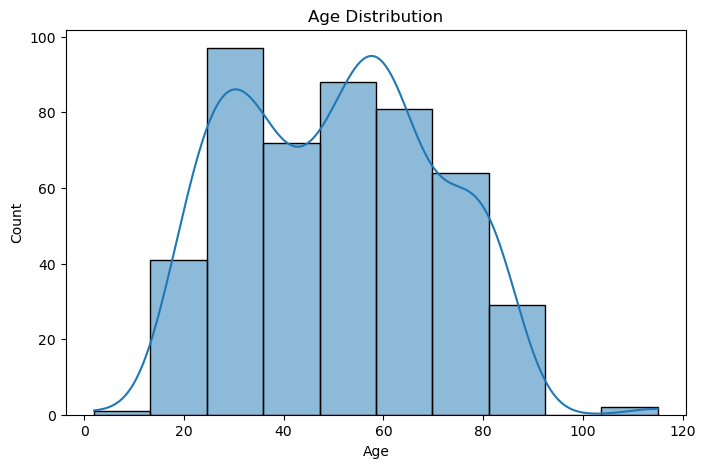

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.show()

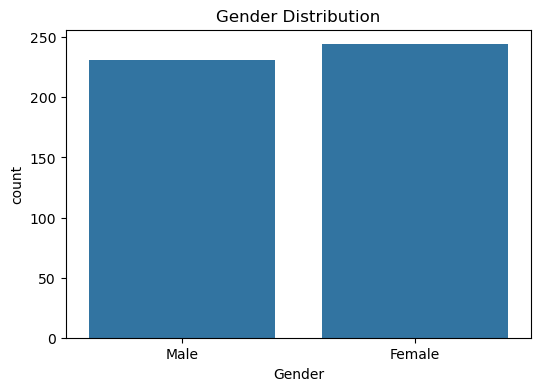

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

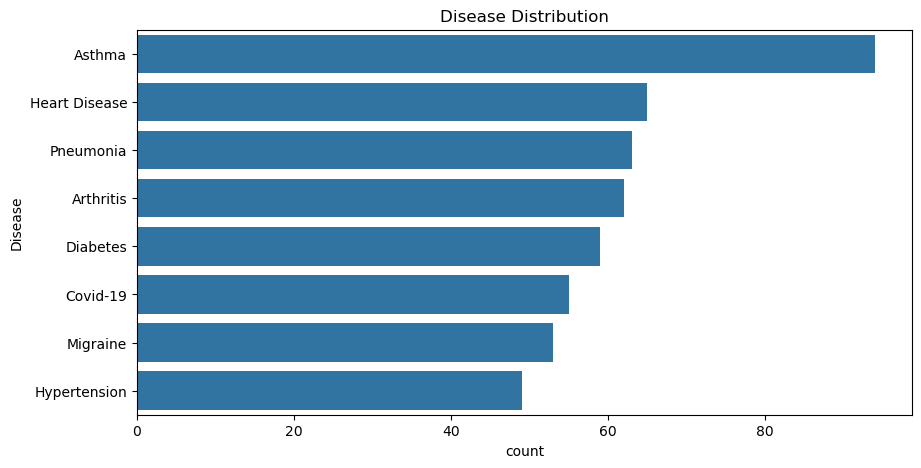

In [43]:
plt.figure(figsize=(10,5))
sns.countplot(y='Disease', data=df, order=df['Disease'].value_counts().index)
plt.title("Disease Distribution")
plt.show()

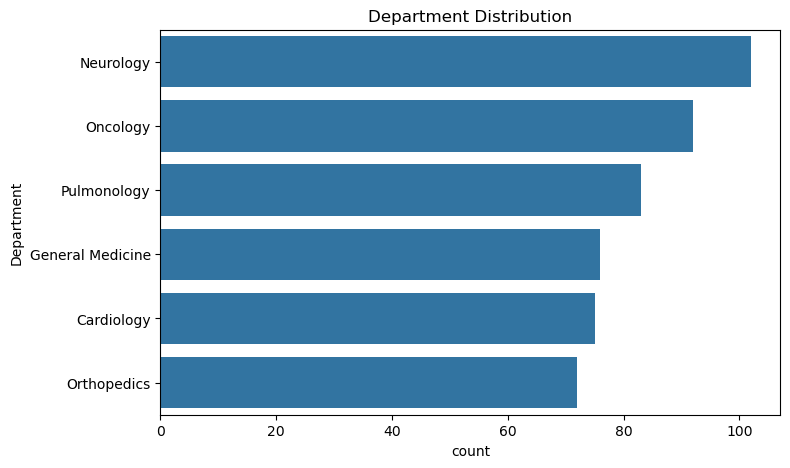

In [44]:
plt.figure(figsize=(8,5))
sns.countplot(y='Department', data=df, order=df['Department'].value_counts().index)
plt.title("Department Distribution")
plt.show()

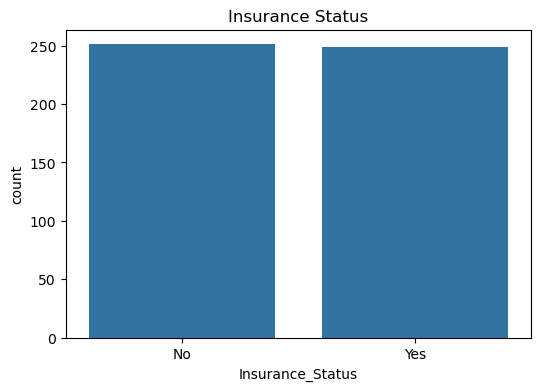

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='Insurance_Status', data=df)
plt.title("Insurance Status")
plt.show()

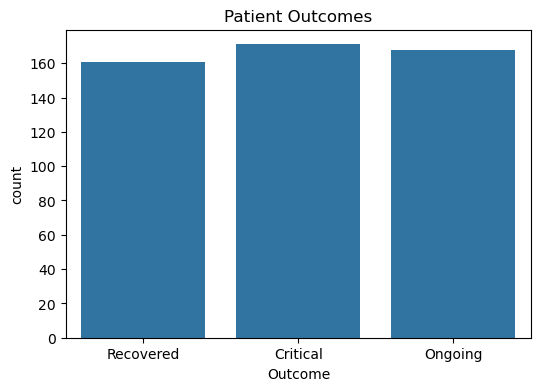

In [46]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title("Patient Outcomes")
plt.show()

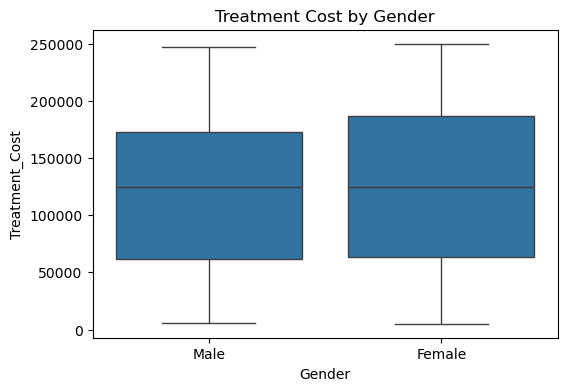

In [47]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Treatment_Cost', data=df)
plt.title("Treatment Cost by Gender")
plt.show()

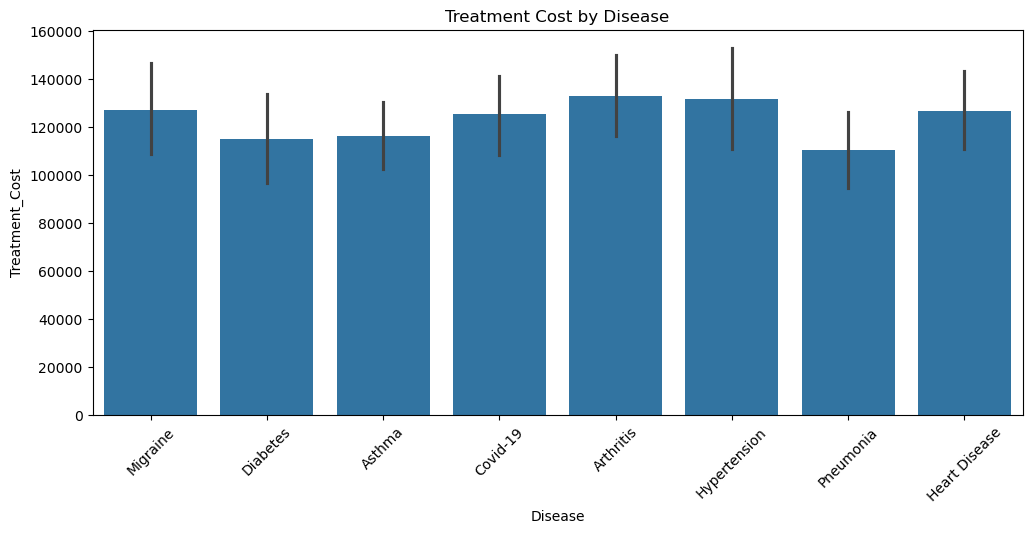

In [48]:
plt.figure(figsize=(12,5))
sns.barplot(x='Disease', y='Treatment_Cost', data=df)
plt.xticks(rotation=45)
plt.title("Treatment Cost by Disease")
plt.show()

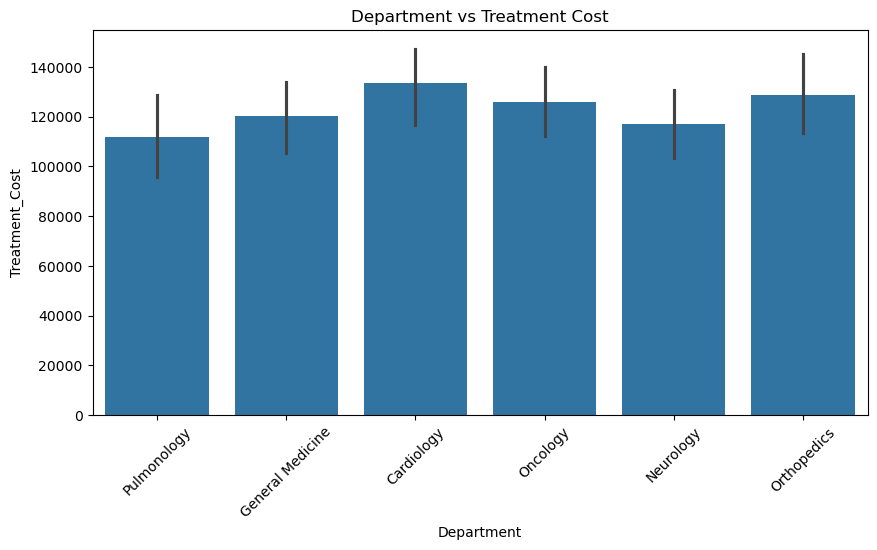

In [49]:
plt.figure(figsize=(10,5))
sns.barplot(x='Department', y='Treatment_Cost', data=df)
plt.xticks(rotation=45)
plt.title("Department vs Treatment Cost")
plt.show()

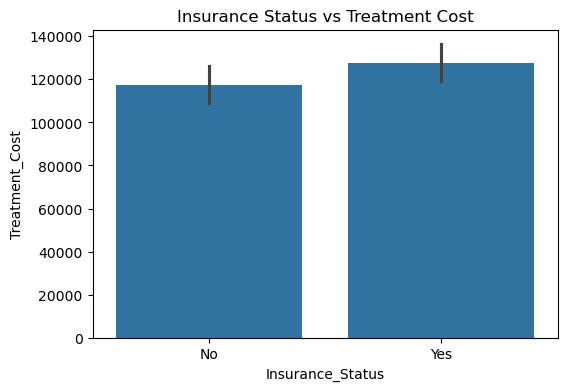

In [50]:
plt.figure(figsize=(6,4))
sns.barplot(x='Insurance_Status', y='Treatment_Cost', data=df)
plt.title("Insurance Status vs Treatment Cost")
plt.show()

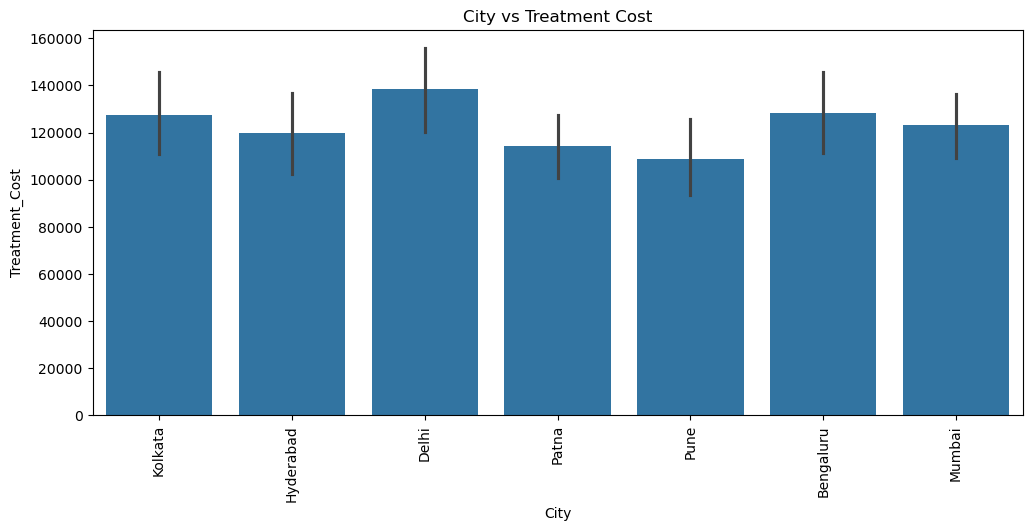

In [51]:
plt.figure(figsize=(12,5))
sns.barplot(x='City', y='Treatment_Cost', data=df)
plt.xticks(rotation=90)
plt.title("City vs Treatment Cost")
plt.show()


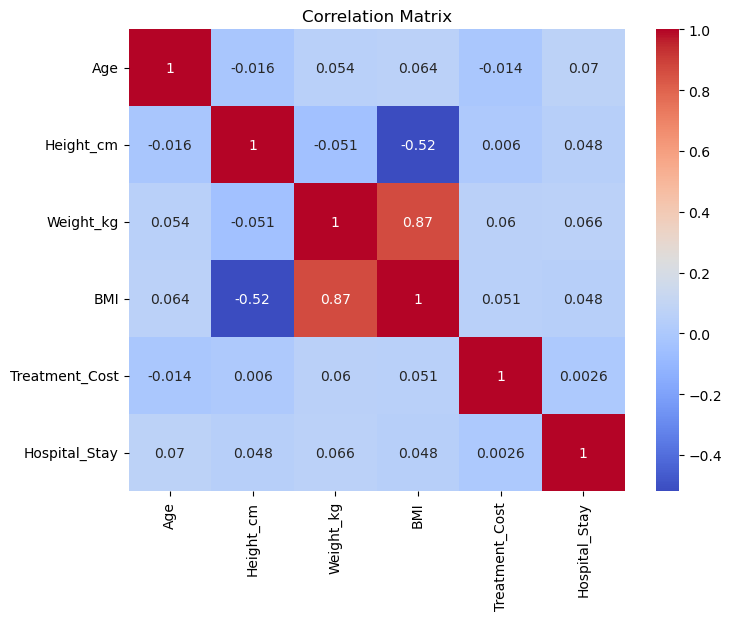

In [52]:
plt.figure(figsize=(8,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Disease
Asthma           10938576.5
Arthritis         8235337.5
Heart Disease     8223494.5
Pneumonia         6954734.5
Covid-19          6902742.5
Diabetes          6776360.0
Migraine          6733805.0
Hypertension      6462863.0
Name: Treatment_Cost, dtype: float64
Highest Cost Disease: Asthma
Total Treatment Cost: 10938576.5


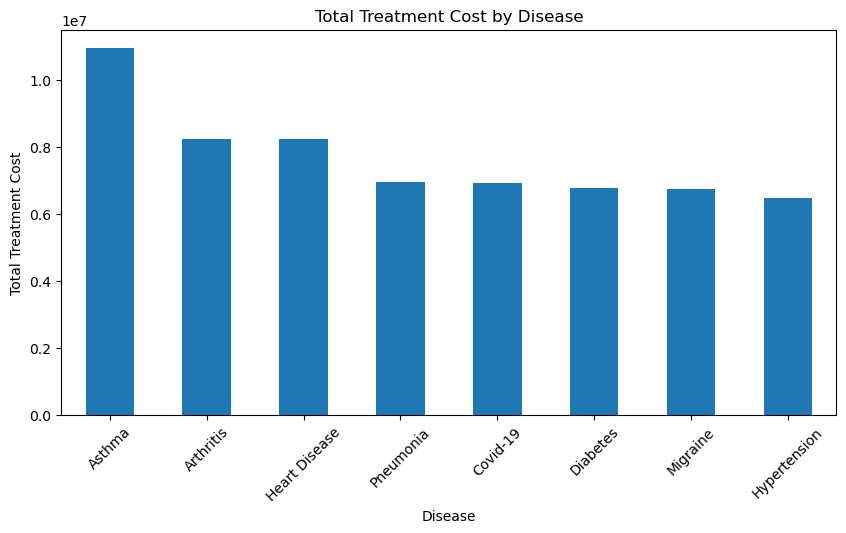

In [53]:
#Q1. Which disease contributes the highest total treatment cost?
disease_cost = df.groupby('Disease')['Treatment_Cost'].sum().sort_values(ascending=False)

print(disease_cost)

highest_disease = disease_cost.idxmax()
highest_cost = disease_cost.max()

print(f"Highest Cost Disease: {highest_disease}")
print(f"Total Treatment Cost: {highest_cost}")

plt.figure(figsize=(10,5))
disease_cost.plot(kind='bar')
plt.title("Total Treatment Cost by Disease")
plt.xlabel("Disease")
plt.ylabel("Total Treatment Cost")
plt.xticks(rotation=45)
plt.show()

In [ ]:
### Insight :Asthma contributes the highest total treatment cost (10,938,576.50) among all diseases in the dataset.
#Arthritis and Heart Disease are the second and third highest contributors, while Hypertension has the lowest total treatment cost.

Department
Neurology           11955993.5
Oncology            11577124.5
Cardiology          10006369.5
Pulmonology          9281318.0
Orthopedics          9274249.5
General Medicine     9132858.5
Name: Treatment_Cost, dtype: float64
Highest Revenue Department: Neurology
Revenue: 11955993.5


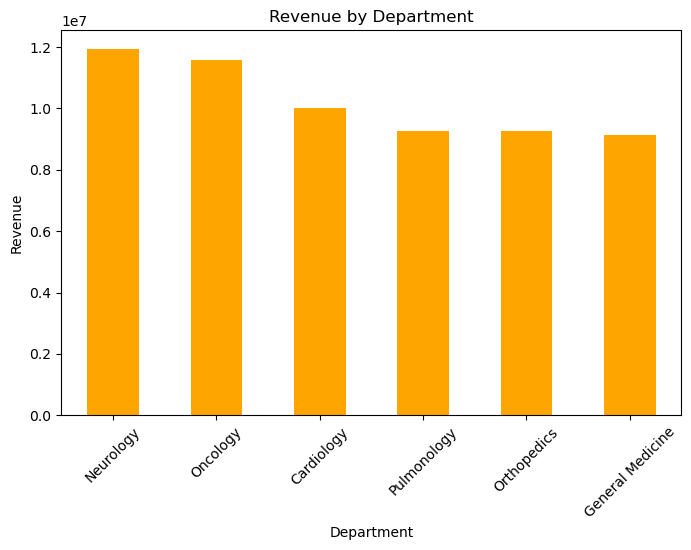

In [54]:

#Q2. Which department generates the highest revenue?
department_revenue = df.groupby('Department')['Treatment_Cost'].sum().sort_values(ascending=False)

print(department_revenue)

highest_department = department_revenue.idxmax()
highest_revenue = department_revenue.max()

print(f"Highest Revenue Department: {highest_department}")
print(f"Revenue: {highest_revenue}")

plt.figure(figsize=(8,5))
department_revenue.plot(kind='bar', color='orange')
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Insight
#Neurology is the highest revenue-generating department with a total revenue of 11,955,993.50, followed by Oncology and Cardiology.

Disease        Insurance_Status
Arthritis      No                  131878.32
               Yes                 133469.72
Asthma         No                  114145.24
               Yes                 119368.34
Covid-19       No                  115925.29
               Yes                 135438.31
Diabetes       No                   94427.96
               Yes                 130946.45
Heart Disease  No                  117683.94
               Yes                 135622.64
Hypertension   No                  139989.50
               Yes                 123463.56
Migraine       No                  111590.06
               Yes                 148841.50
Pneumonia      No                  119453.21
               Yes                 102664.46
Name: Treatment_Cost, dtype: float64


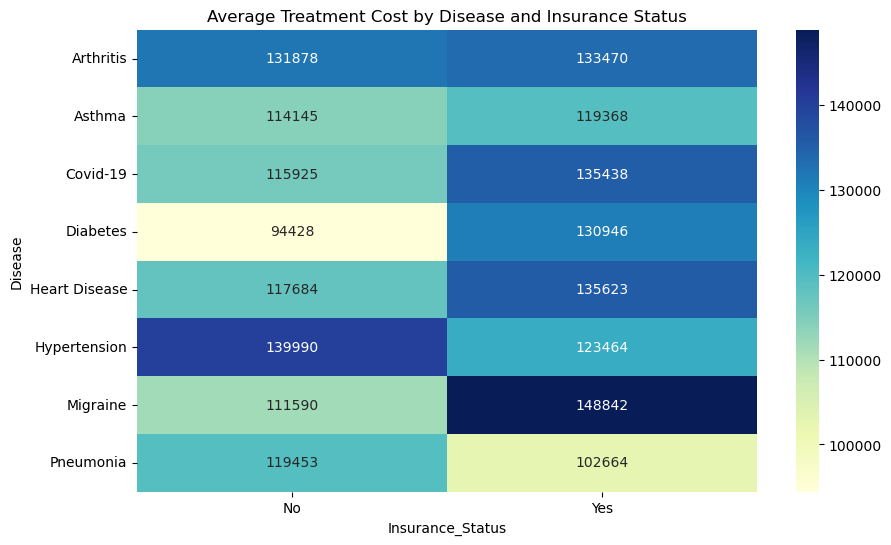

In [56]:
#Q3. What is the average treatment cost by disease and insurance status?
avg_cost = df.groupby(['Disease','Insurance_Status'])['Treatment_Cost'].mean().round(2)

print(avg_cost)

pivot = df.pivot_table(
    values='Treatment_Cost',
    index='Disease',
    columns='Insurance_Status',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Treatment Cost by Disease and Insurance Status")
plt.show()

In [ ]:
#Insight
#Insured patients have the highest average treatment cost for Migraine (148,841.50), while uninsured patients have the highest average treatment cost for Hypertension (139,989.50). Average treatment costs differ across diseases and insurance status.

In [57]:
#Q4. What percentage of total treatment costs are covered by insured patients?
total_cost = df['Treatment_Cost'].sum()

insured_cost = df[df['Insurance_Status']=='Yes']['Treatment_Cost'].sum()

percentage = (insured_cost/total_cost)*100

print(f"Total Cost: {total_cost}")
print(f"Insured Cost: {insured_cost}")
print(f"Percentage Covered: {percentage:.2f}%")

Total Cost: 61227913.5
Insured Cost: 31759335.0
Percentage Covered: 51.87%


In [ ]:
#Insight
#Approximately 51.87% of the total treatment cost is covered by insured patients, showing that insurance plays a significant role in financing healthcare expenses.

City
Delhi        138487.949153
Bengaluru    128335.271429
Kolkata      127367.133803
Mumbai       123011.487952
Hyderabad    119676.061644
Patna        114257.259740
Pune         108753.343284
Name: Treatment_Cost, dtype: float64
Highest Average Cost City: Delhi
Average Cost: 138487.94915254237


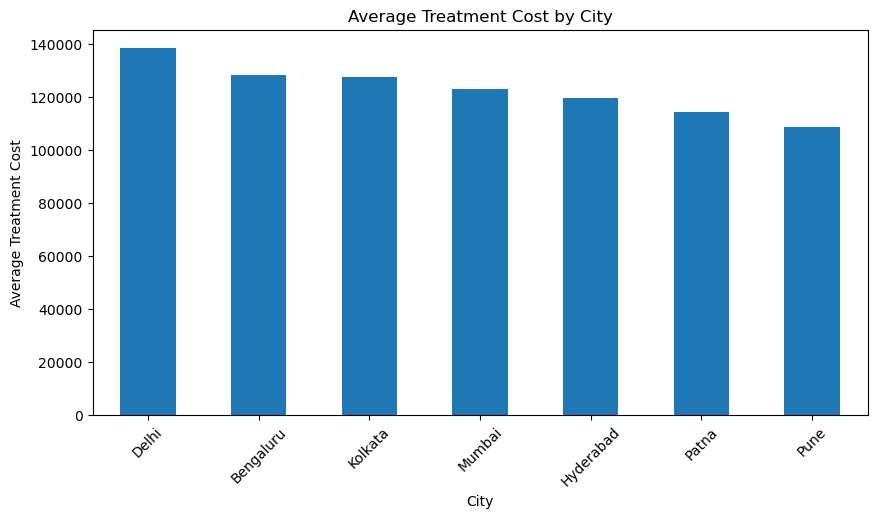

In [58]:
#Q5. Which city has the highest average treatment cost per patient?
city_cost = df.groupby('City')['Treatment_Cost'].mean().sort_values(ascending=False)

print(city_cost)

highest_city = city_cost.idxmax()
highest_avg = city_cost.max()

print(f"Highest Average Cost City: {highest_city}")
print(f"Average Cost: {highest_avg}")

plt.figure(figsize=(10,5))
city_cost.plot(kind='bar')
plt.title("Average Treatment Cost by City")
plt.ylabel("Average Treatment Cost")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Insight
#Delhi records the highest average treatment cost per patient (138,487.95), followed by Bengaluru and Kolkata.

C:\Users\RUSHIKESH\AppData\Local\Temp\ipykernel_25516\1221767554.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_cost = df.groupby('Age_Group')['Treatment_Cost'].sum().sort_values(ascending=False)


Age_Group
60+      19891017.5
46-60    13672302.0
31-45    12782109.5
18-30    11547389.5
Name: Treatment_Cost, dtype: float64


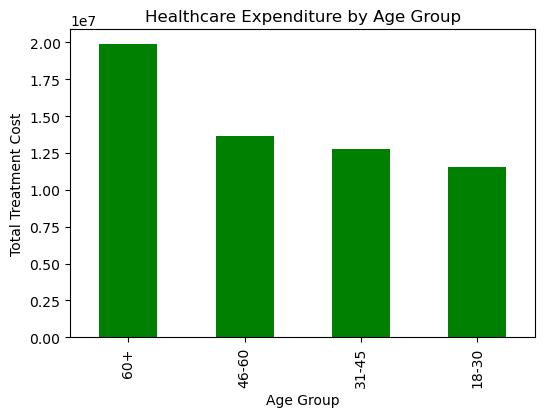

In [59]:
#Q6. Which age group contributes the highest healthcare expenditure?
bins = [18,30,45,60,100]
labels = ['18-30','31-45','46-60','60+']

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_cost = df.groupby('Age_Group')['Treatment_Cost'].sum().sort_values(ascending=False)

print(age_cost)

plt.figure(figsize=(6,4))
age_cost.plot(kind='bar', color='green')
plt.title("Healthcare Expenditure by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Treatment Cost")
plt.show()

In [ ]:
#Insight
#Patients aged 60+ contribute the highest healthcare expenditure (19,891,017.50), while the 18–30 age group contributes the least.

Disease    Arthritis  Asthma  Covid-19  Diabetes  Heart Disease  Hypertension  \
Age_Group                                                                       
18-30             13      19        12         9             10             9   
31-45             14      21        10        11             15            11   
46-60             20      19        13        16             15            11   
60+               15      31        16        20             20            15   

Disease    Migraine  Pneumonia  
Age_Group                       
18-30            14          9  
31-45             9         11  
46-60            13         11  
60+              14         26  


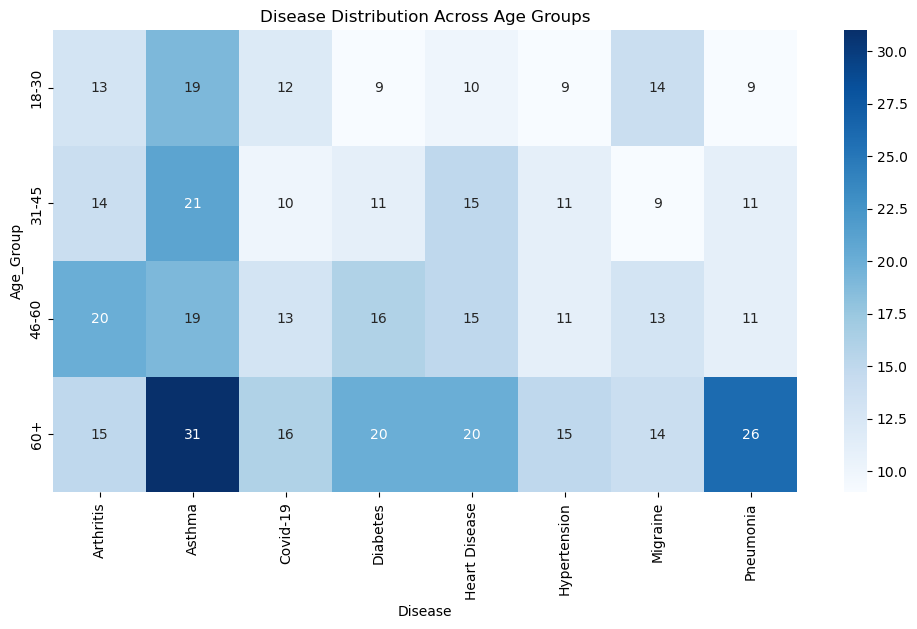

In [60]:
#Q7. What diseases are most common among different age groups?
disease_age = pd.crosstab(df['Age_Group'], df['Disease'])

print(disease_age)

plt.figure(figsize=(12,6))
sns.heatmap(disease_age, annot=True, cmap='Blues')
plt.title("Disease Distribution Across Age Groups")
plt.show()

In [ ]:
#Insight
#Asthma is the most common disease in the 18–30, 31–45, and 60+ age groups, while Arthritis is the most common disease in the 46–60 age group. The 60+ age group records the highest number of Asthma (31) and Pneumonia (26) cases, indicating that these conditions are more prevalent among older patients

Gender
Female    123123.622951
Male      120195.606061
Name: Treatment_Cost, dtype: float64


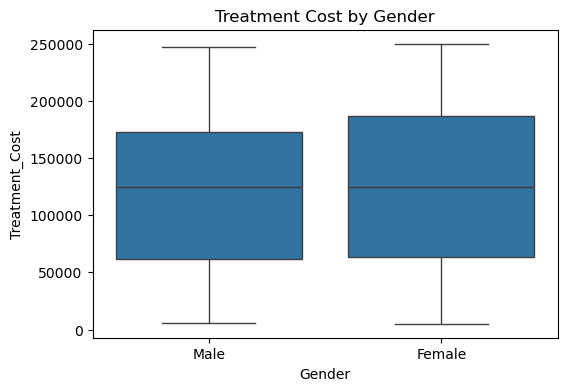

In [61]:
#Q8. Is there a significant difference in treatment costs between male and female patients?
gender_cost = df.groupby('Gender')['Treatment_Cost'].mean()

print(gender_cost)

plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Treatment_Cost', data=df)
plt.title("Treatment Cost by Gender")
plt.show()

In [ ]:
#Insight
#Female patients have a slightly higher average treatment cost (123,123.62) than male patients (120,195.61). However, the difference is relatively small, suggesting that treatment costs are broadly similar for both genders in this dataset.

Blood_Group
Ab-    25
B+     23
Ab+    23
O-     22
A+     20
B-     19
A-     16
O+     15
Name: count, dtype: int64


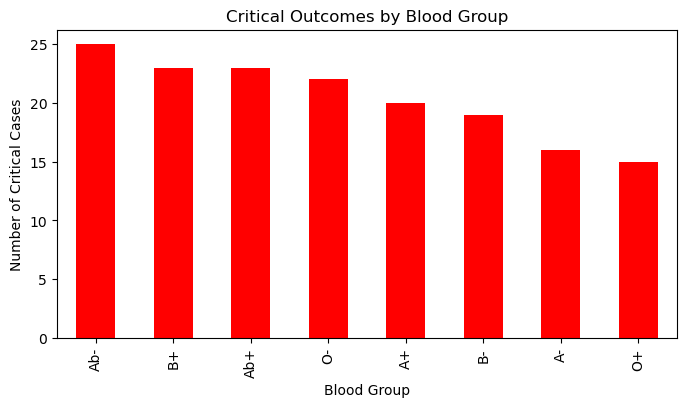

In [62]:
#Q9. Which blood group has the highest incidence of critical outcomes?
critical = df[df['Outcome']=='Critical']

blood_group = critical['Blood_Group'].value_counts()

print(blood_group)

plt.figure(figsize=(8,4))
blood_group.plot(kind='bar', color='red')
plt.title("Critical Outcomes by Blood Group")
plt.xlabel("Blood Group")
plt.ylabel("Number of Critical Cases")
plt.show()

In [ ]:
# Insight   
#AB- blood group has the highest incidence of critical outcomes, with 25 critical cases. B+ and AB+ follow with 23 cases each, while O+ has the lowest number of critical outcomes (15). This indicates that AB- recorded the highest number of critical cases in this dataset.

In [ ]:
## Key Insights

• Asthma contributes the highest total treatment cost (10,938,576.50).

• Neurology is the highest revenue-generating department (11,955,993.50).

• Insured patients account for 51.87% of the total treatment cost.

• Delhi has the highest average treatment cost per patient (138,487.95).

• The 60+ age group contributes the highest healthcare expenditure (19,891,017.50).

• Asthma is the most common disease across most age groups, while Arthritis is most common in the 46–60 age group.

• Female patients have a slightly higher average treatment cost than male patients, but the difference is small.

• AB- blood group has the highest number of critical outcomes (25 cases).

In [ ]:
## Conclusion

#The healthcare dataset was cleaned and analyzed to identify key business and patient demographic trends. Asthma accounted for the highest treatment cost, while Neurology generated the highest revenue. Insured patients covered more than half of the total treatment costs. Older patients (60+) contributed the highest healthcare expenditure, and Delhi recorded the highest average treatment cost per patient. These insights can help healthcare organizations better understand cost distribution, patient demographics, and resource allocation.

In [63]:
df.to_csv("cleaned_healthcare_dataset.csv", index=False)

In [64]:
import os

print(os.getcwd())

C:\Users\RUSHIKESH
